# 参考mnist_conv-keras实现针对cifar10的alexNet卷积模型


#### 链接: https://pan.baidu.com/s/1LcCPcK9DgLS3W_DUPZS8kQ 提取码: 5vwz
### 解压放到 ~/.keras/datasets/

## tar zxvf cifar***.tar.zip

## 准备数据

In [21]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, datasets
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def cifar10_dataset():
    (x, y), (x_test, y_test) = datasets.cifar10.load_data()
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(prepare_mnist_features_and_labels)
    ds = ds.shuffle(50000).batch(100)  # 使用全部训练数据
    
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = test_ds.map(prepare_mnist_features_and_labels)
    test_ds = test_ds.batch(100)  # 使用全部测试数据
    return ds, test_ds

def prepare_mnist_features_and_labels(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    y = tf.cast(y, tf.int64)
    y = tf.squeeze(y)
    return x, y

## 建立模型

In [22]:
class myConvModel(keras.Model):
    '''在这里实现alexNet模型'''
    def __init__(self):
        super(myConvModel, self).__init__()
        self.l1_conv = Conv2D(filters=32, 
                              kernel_size=(5, 5), 
                              activation='relu', 
                              padding='same',
                              name='conv1')
        
        self.pool1 = MaxPooling2D(pool_size=(2, 2), strides=2, name='pool1')
        
        self.l2_conv = Conv2D(filters=64, 
                              kernel_size=(5, 5), 
                              activation='relu',
                              padding='same',
                              name='conv2')
        
        self.pool2 = MaxPooling2D(pool_size=(2, 2), strides=2, name='pool2')
        
        self.flat = Flatten(name='flatten')
        self.dense1 = layers.Dense(100, activation='tanh', name='dense1')
        self.dense2 = layers.Dense(10, name='dense2')
    
    def call(self, x, training=False):
        h1 = self.l1_conv(x) 
        h1_pool = self.pool1(h1) 
        h2 = self.l2_conv(h1_pool)
        h2_pool = self.pool2(h2) 
        flat_h = self.flat(h2_pool)
        dense1 = self.dense1(flat_h)
        logits = self.dense2(dense1)
        return logits
    
    def getL1_feature_map(self, x):
        h1 = self.l1_conv(x)
        return h1
    
    def getL2_feature_map(self, x):
        h1 = self.l1_conv(x)
        h1_pool = self.pool1(h1)
        h2 = self.l2_conv(h1_pool)
        return h2

model = myConvModel()
optimizer = optimizers.Adam(0.001)

In [23]:
# 诊断数据集
train_ds, test_ds = cifar10_dataset()

for batch_x, batch_y in train_ds.take(1):
    print(f"Batch X shape: {batch_x.shape}")
    print(f"Batch Y shape: {batch_y.shape}")
    print(f"Batch Y sample: {batch_y[:10]}")
    print(f"Batch Y dtype: {batch_y.dtype}")
    
    # 测试模型输出
    output = model(batch_x[:5])
    print(f"\nModel output shape: {output.shape}")
    print(f"Model output sample:\n{output[0]}")
    
    # 测试损失计算
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    loss = loss_fn(batch_y[:5], output)
    print(f"\nLoss: {loss}")
    break

Batch X shape: (100, 32, 32, 3)
Batch Y shape: (100,)
Batch Y sample: [4 6 8 6 4 2 9 3 3 4]
Batch Y dtype: <dtype: 'int64'>

Model output shape: (5, 10)
Model output sample:
[-0.00287683 -0.28636366  0.11793713 -0.50983953 -0.03304727 -0.18000093
 -0.36413574  0.15891534  0.26071462 -0.16893843]

Loss: 2.3438868522644043


In [24]:
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
train_ds, test_ds = cifar10_dataset()
model.fit(train_ds, epochs=15)
model.evaluate(test_ds)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4940 - loss: 1.4206
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6308 - loss: 1.0449
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6849 - loss: 0.8903
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7231 - loss: 0.7886
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7578 - loss: 0.6953
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7880 - loss: 0.6095
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8149 - loss: 0.5357
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8423 - loss: 0.4594
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8712 - loss: 0.3849
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8955 - loss: 0.3196
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9186 - loss: 0.2597
Epoch 12/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6

[1.1546447277069092, 0.7111999988555908]

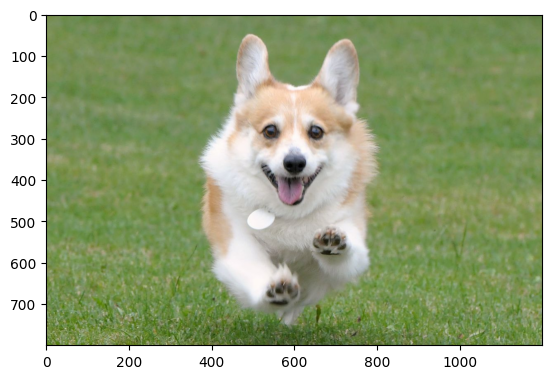

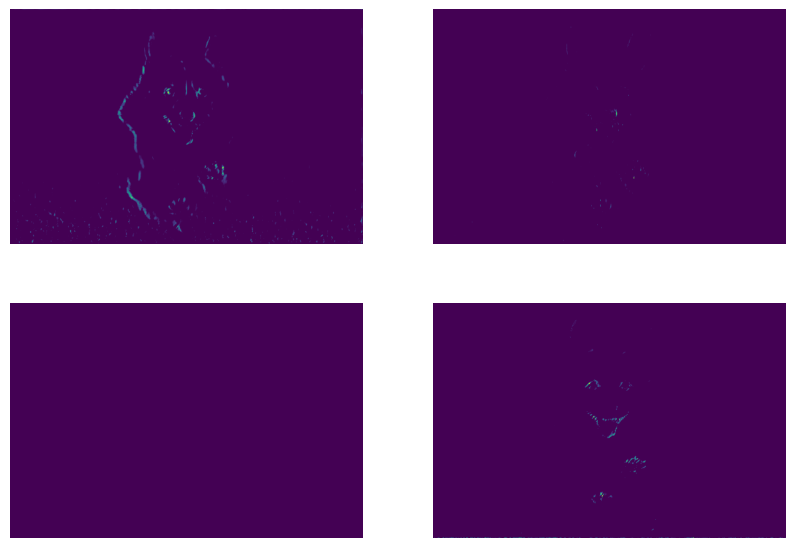

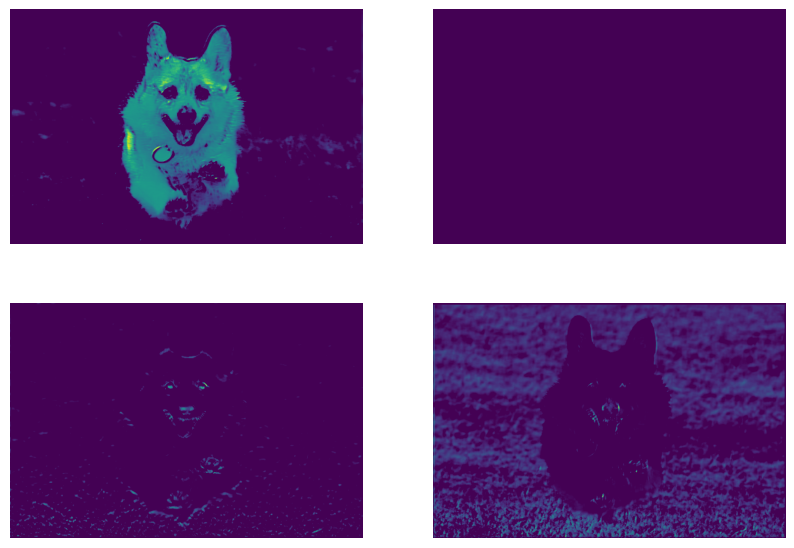

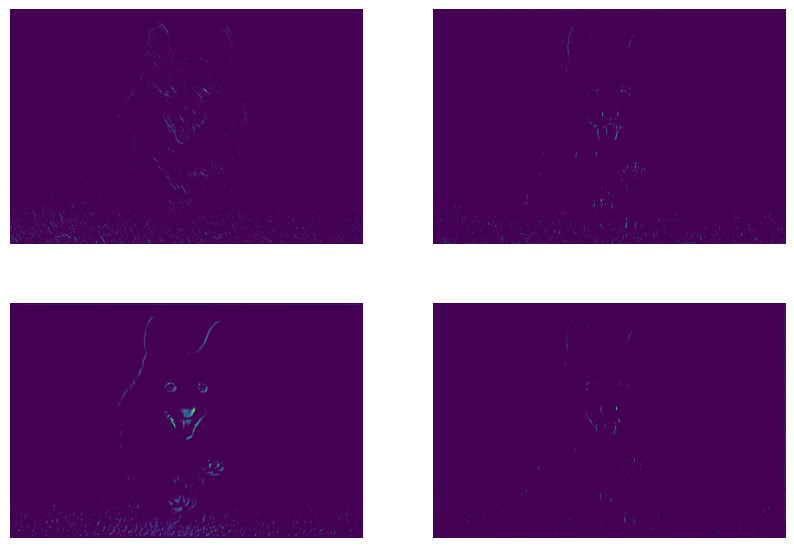

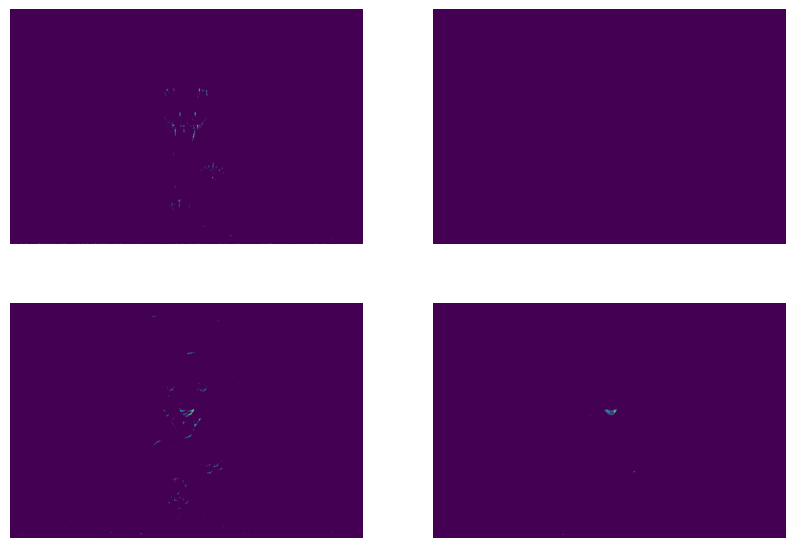

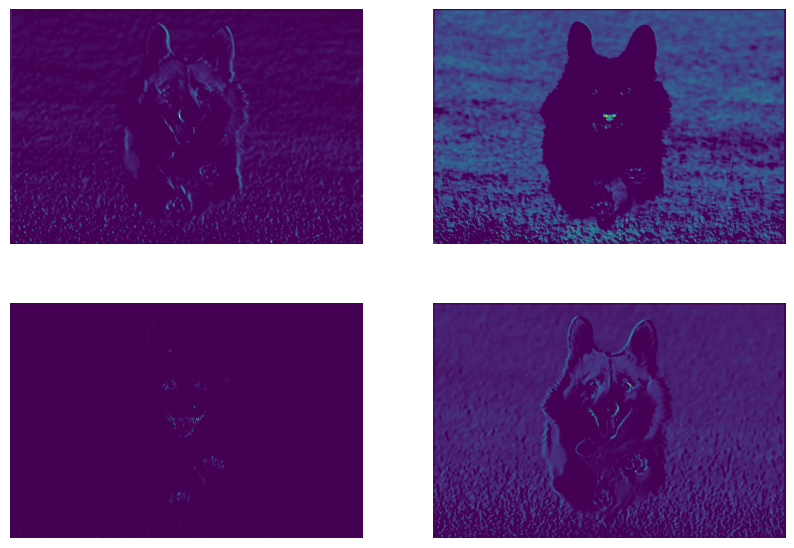

In [25]:

import numpy
import pylab
from PIL import Image
import numpy as np

ds, test_ds = cifar10_dataset()

for i in test_ds:
    test_batch = i[0][:1, :, :]
    break
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float32') / 256.
# print(img.shape)
img = np.expand_dims(img, axis=0)

# img = test_batch
img_out = model.getL2_feature_map(img)
pylab.imshow(img[0, :, :, :])

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 3])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 4])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 5])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 6])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 7])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 8])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 9])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 10])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 11])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 12])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 13])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 14])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 15])
pylab.show()


pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 16])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 17])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 18])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 19])
pylab.show()



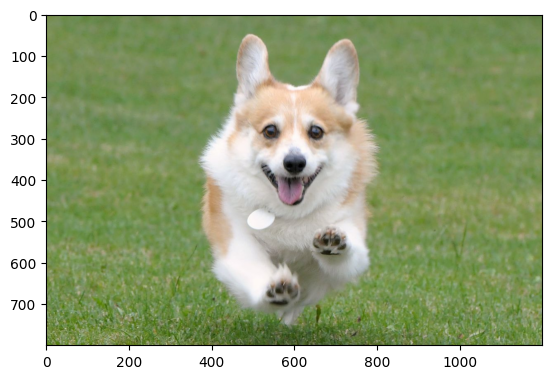

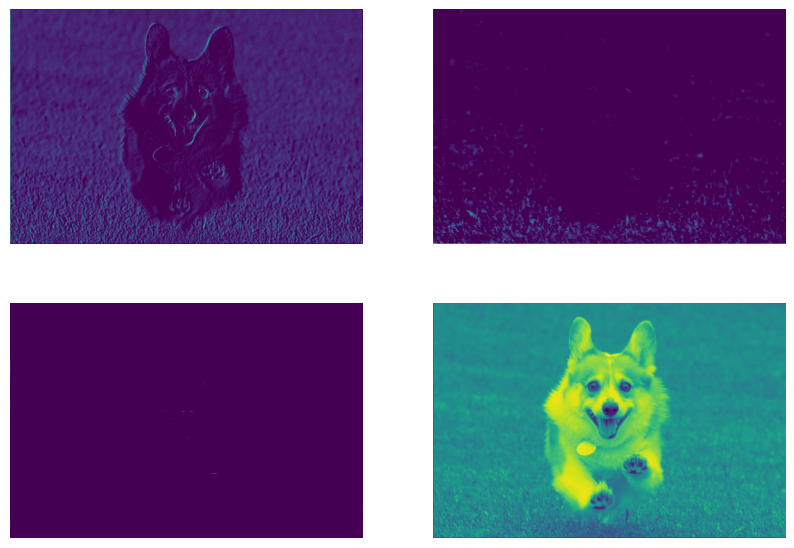

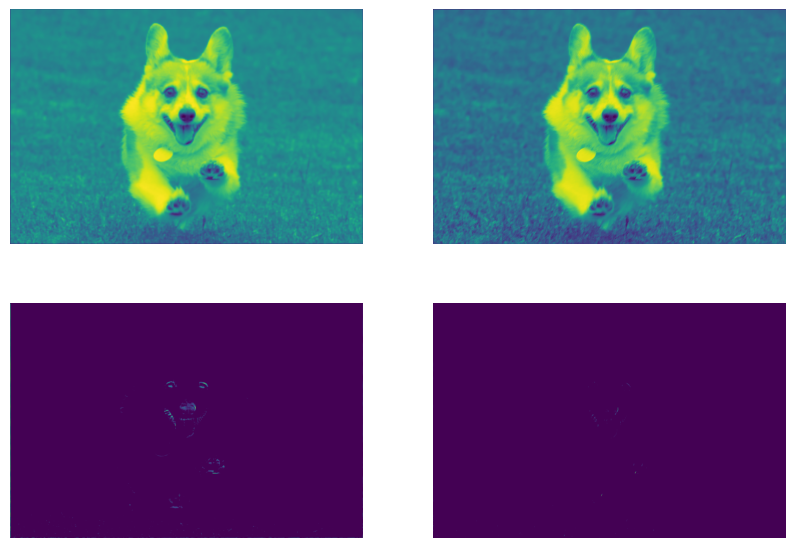

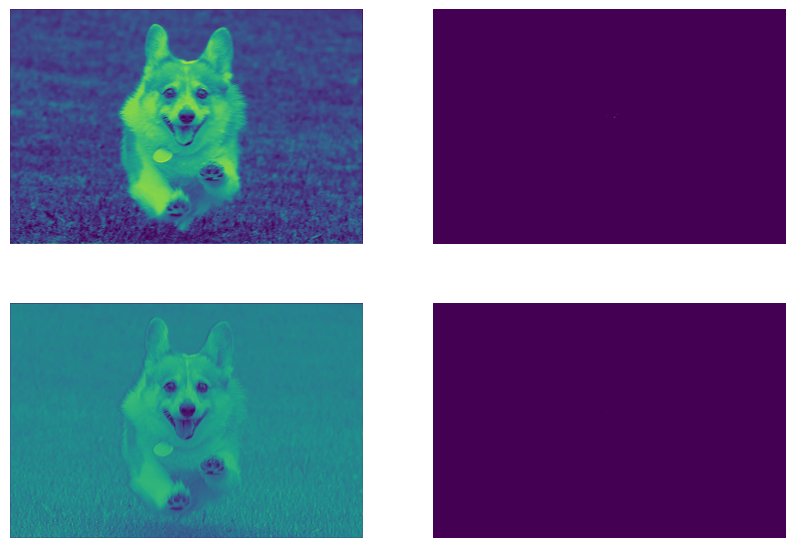

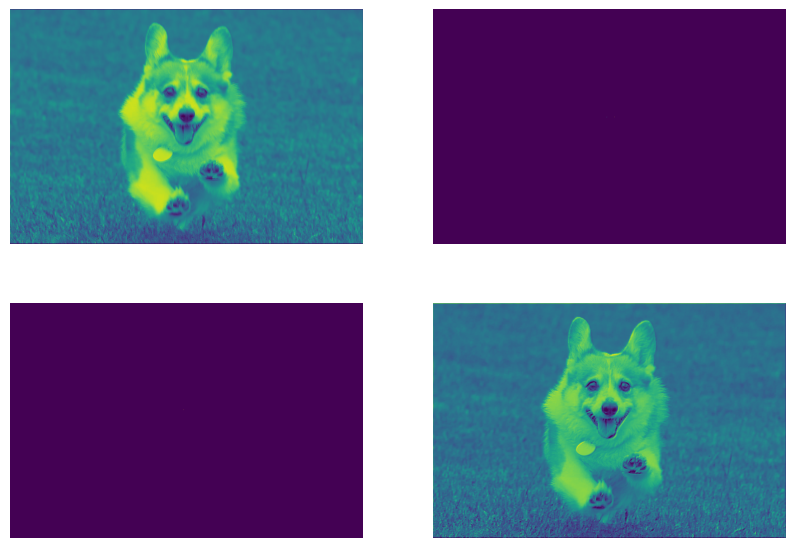

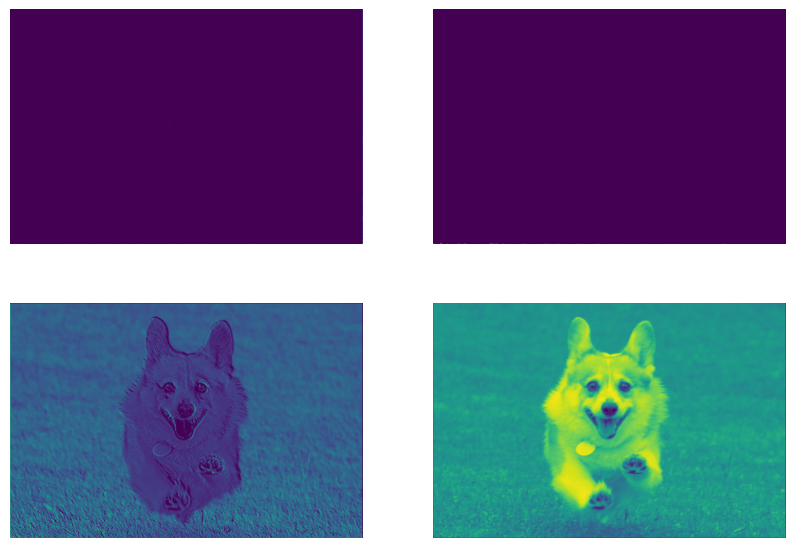

In [26]:
import numpy
import pylab
from PIL import Image
import numpy as np
rand_model = myConvModel()
ds, test_ds = cifar10_dataset()

for i in test_ds:
    test_batch = i[0][:1, :, :]
    break
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float32') / 256.
# print(img.shape)
img = np.expand_dims(img, axis=0)

# img = test_batch
img_out = rand_model.getL1_feature_map(img)
pylab.imshow(img[0, :, :, :])

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 3])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 4])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 5])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 6])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 7])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 8])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 9])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 10])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 11])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 12])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 13])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 14])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 15])
pylab.show()


pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 16])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 17])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 18])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 19])
pylab.show()

